# Customer Segmentation Project

## Objective

The objective of this project is to segment customers based on their purchasing behavior and demographic characteristics.

K-Means clustering is used to identify groups of customers with similar annual income and spending behavior.

## Tools Used

- Python
- Pandas
- Matplotlib
- Scikit-learn
- Google Colab

## Dataset

Mall Customers Dataset containing customer information such as age, genre, annual income and spending score.

## Methodology

1. Load the customer dataset.
2. Explore the dataset and check for missing values.
3. Select Annual Income and Spending Score as clustering features.
4. Use the Elbow Method to determine the optimal number of clusters.
5. Apply K-Means clustering with 5 clusters.
6. Analyze the characteristics of each customer segment.
7. Visualize the customer segments and key characteristics.
8. Export the final segmented dataset.

## Customer Segments

The analysis identified five customer segments:

1. **Average Customers** – Moderate income and moderate spending.
2. **High-Value Customers** – High income and high spending.
3. **Low-Income High Spenders** – Low income but high spending.
4. **High-Income Low Spenders** – High income but low spending.
5. **Low-Income Low Spenders** – Low income and low spending.

## Key Business Insights

- High-Value Customers are important customers and should be retained through loyalty programs and personalized offers.
- Low-Income High Spenders show strong purchasing engagement.
- High-Income Low Spenders represent an opportunity for targeted promotions.
- Average Customers have moderate income and spending behavior.
- Low-Income Low Spenders have relatively low purchasing activity.

## Conclusion

K-Means clustering successfully divided customers into five meaningful groups based on income and spending behavior. These segments can help businesses understand customer preferences and develop targeted marketing strategies.

In [ ]:
import pandas as pd

df = pd.read_csv("/Mall_Customers.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/Mall_Customers.csv'

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/refs/heads/master/Mall_Customers.csv"

df = pd.read_csv(url)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [ ]:
cluster_names = {
    0: 'Average Customers',
    1: 'High-Value Customers',
    2: 'Low-Income High Spenders',
    3: 'High-Income Low Spenders',
    4: 'Low-Income Low Spenders'
}

df['Segment'] = df['cluster'].map(cluster_names)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster,Segment
0,1,Male,19,15,39,4,Low-Income Low Spenders
1,2,Male,21,15,81,2,Low-Income High Spenders
2,3,Female,20,16,6,4,Low-Income Low Spenders
3,4,Female,23,16,77,2,Low-Income High Spenders
4,5,Female,31,17,40,4,Low-Income Low Spenders


In [ ]:
df[['CustomerID', 'Age', 'Genre', 'Annual Income (k$)',
    'Spending Score (1-100)', 'cluster', 'Segment']].head(10)

,CustomerID,Age,Genre,Annual Income (k$),Spending Score (1-100),cluster,Segment
0,1,19,Male,15,39,4,Low-Income Low Spenders
1,2,21,Male,15,81,2,Low-Income High Spenders
2,3,20,Female,16,6,4,Low-Income Low Spenders
3,4,23,Female,16,77,2,Low-Income High Spenders
4,5,31,Female,17,40,4,Low-Income Low Spenders
5,6,22,Female,17,76,2,Low-Income High Spenders
6,7,35,Female,18,6,4,Low-Income Low Spenders
7,8,23,Female,18,94,2,Low-Income High Spenders
8,9,64,Male,19,3,4,Low-Income Low Spenders
9,10,30,Female,19,72,2,Low-Income High Spenders


In [ ]:
df.groupby('Segment')['Age'].mean().sort_values()

,Age
Segment,
Low-Income High Spenders,25.272727
High-Value Customers,32.692308
High-Income Low Spenders,41.114286
Average Customers,42.716049
Low-Income Low Spenders,45.217391


In [ ]:
pd.crosstab(df['Segment'], df['Genre'])

Genre,Female,Male
Segment,,
Average Customers,48,33
High-Income Low Spenders,16,19
High-Value Customers,21,18
Low-Income High Spenders,13,9
Low-Income Low Spenders,14,9


NameError: name 'plt' is not defined

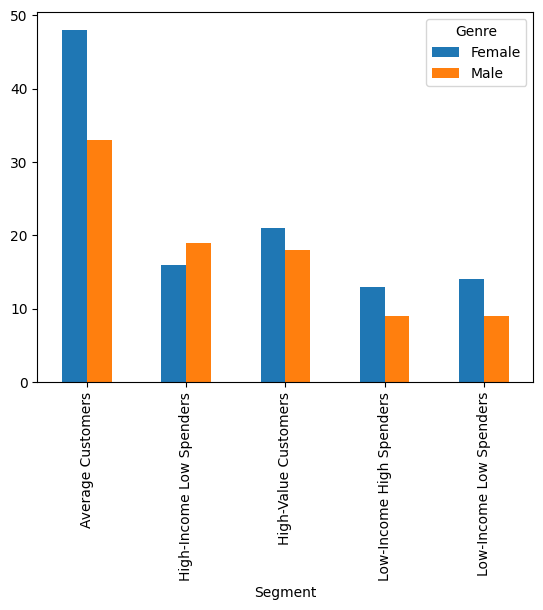

In [ ]:
pd.crosstab(df['Segment'], df['Genre']).plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Genre Distribution by Customer Segment')
plt.xticks(rotation=45)
plt.legend(title='Genre')
plt.show()

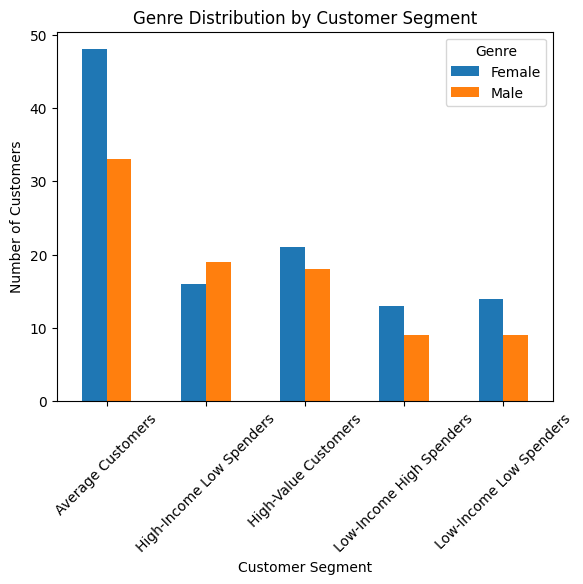

In [ ]:
import matplotlib.pyplot as plt

pd.crosstab(df['Segment'], df['Genre']).plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Genre Distribution by Customer Segment')
plt.xticks(rotation=45)
plt.legend(title='Genre')
plt.show()

In [ ]:
segment_summary = df.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    Average_Age=('Age', 'mean'),
    Average_Income=('Annual Income (k$)', 'mean'),
    Average_Spending=('Spending Score (1-100)', 'mean')
).round(2)

segment_summary

,Customers,Average_Age,Average_Income,Average_Spending
Segment,,,,
Average Customers,81,42.72,55.30,49.52
High-Income Low Spenders,35,41.11,88.20,17.11
High-Value Customers,39,32.69,86.54,82.13
Low-Income High Spenders,22,25.27,25.73,79.36
Low-Income Low Spenders,23,45.22,26.30,20.91


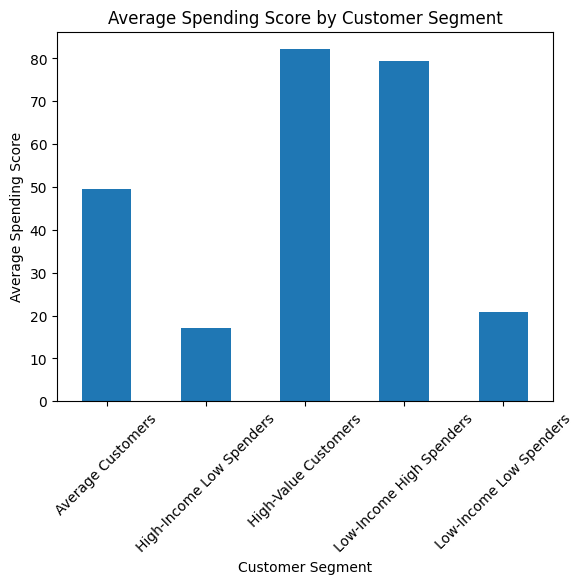

In [ ]:
segment_summary['Average_Spending'].plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Average Spending Score')
plt.title('Average Spending Score by Customer Segment')
plt.xticks(rotation=45)
plt.show()

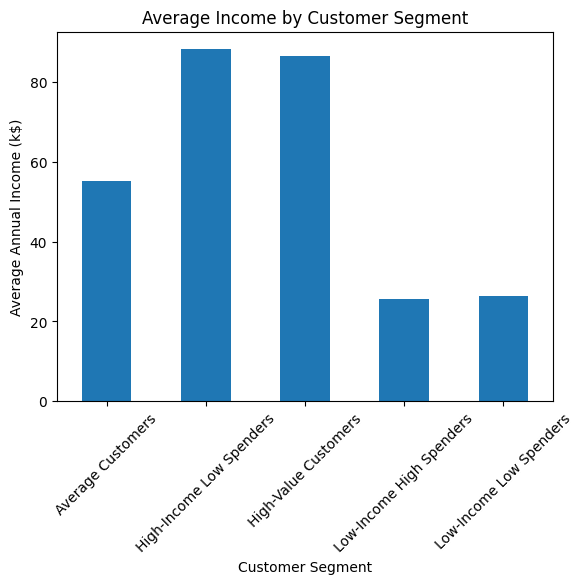

In [ ]:
segment_summary['Average_Income'].plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Average Annual Income (k$)')
plt.title('Average Income by Customer Segment')
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.to_csv("Customer_Segmentation_Final.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!


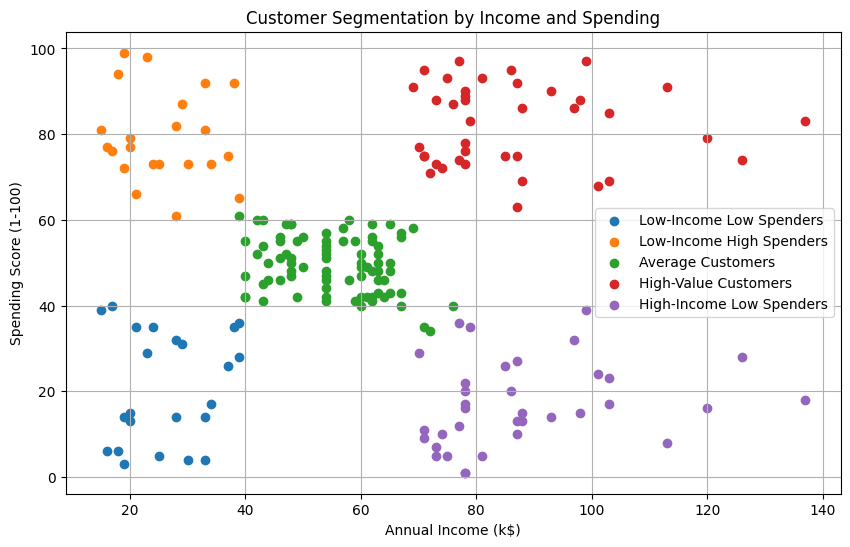

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for segment in df['Segment'].unique():
    data = df[df['Segment'] == segment]
    plt.scatter(
        data['Annual Income (k$)'],
        data['Spending Score (1-100)'],
        label=segment
    )

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation by Income and Spending')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import os

print(os.getcwd())
print(os.listdir("/"))

/content
['var', 'tmp', 'opt', 'sys', 'lib64', 'etc', 'proc', 'usr', 'root', 'home', 'boot', 'dev', 'bin', 'run', 'srv', 'sbin', 'mnt', 'lib', 'media', '.ipynb_checkpoints', 'Mall_Customers.csv ', 'kaggle', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz', 'bin.usr-is-merged', 'sbin.usr-is-merged', 'lib.usr-is-merged']


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/sharmaroshan/Clustering-of-Mall-Customers/refs/heads/master/Mall_Customers.csv"

df = pd.read_csv(url)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


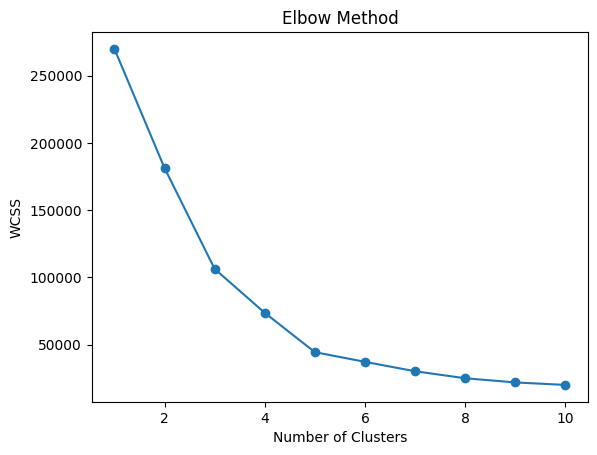

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


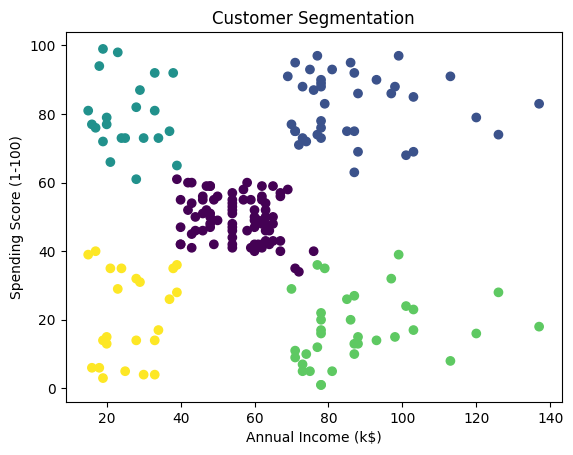

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation')
plt.show()

In [ ]:
df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


In [ ]:
cluster_names = {
    0: 'Average Customers',
    1: 'High-Value Customers',
    2: 'Low-Income High Spenders',
    3: 'High-Income Low Spenders',
    4: 'Low-Income Low Spenders'
}

df['Segment'] = df['Cluster'].map(cluster_names)

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment
0,1,Male,19,15,39,4,Low-Income Low Spenders
1,2,Male,21,15,81,2,Low-Income High Spenders
2,3,Female,20,16,6,4,Low-Income Low Spenders
3,4,Female,23,16,77,2,Low-Income High Spenders
4,5,Female,31,17,40,4,Low-Income Low Spenders


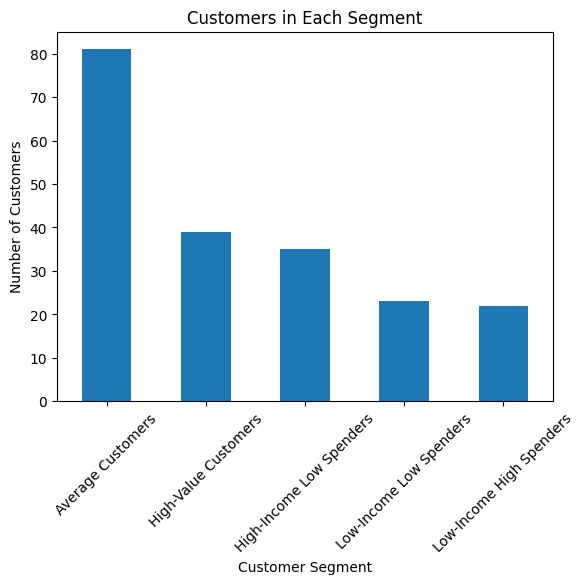

In [ ]:
df['Segment'].value_counts().plot(kind='bar')

plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.title('Customers in Each Segment')
plt.xticks(rotation=45)
plt.show()

In [ ]:
cluster_names = {
    0: "Average Customers",
    1: "High-Value Customers",
    2: "High-Income Low Spenders",
    3: "Low-Income Low Spenders",
    4: "Low-Income High Spenders"
}

df["Segment"] = df["cluster"].map(cluster_names)

df[["CustomerID", "Annual Income (k$)", "Spending Score (1-100)", "Segment"]].head(10)

,CustomerID,Annual Income (k$),Spending Score (1-100),Segment
0,1,15,39,Low-Income High Spenders
1,2,15,81,High-Income Low Spenders
2,3,16,6,Low-Income High Spenders
3,4,16,77,High-Income Low Spenders
4,5,17,40,Low-Income High Spenders
5,6,17,76,High-Income Low Spenders
6,7,18,6,Low-Income High Spenders
7,8,18,94,High-Income Low Spenders
8,9,19,3,Low-Income High Spenders
9,10,19,72,High-Income Low Spenders


In [ ]:
from sklearn.cluster import KMeans

# Select features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Create K-Means model with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Create cluster labels
df['cluster'] = kmeans.fit_predict(X)

# Check the result
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster,Segment,cluster
0,1,Male,19,15,39,4,Low-Income Low Spenders,4
1,2,Male,21,15,81,2,Low-Income High Spenders,2
2,3,Female,20,16,6,4,Low-Income Low Spenders,4
3,4,Female,23,16,77,2,Low-Income High Spenders,2
4,5,Female,31,17,40,4,Low-Income Low Spenders,4
